<a href="https://colab.research.google.com/github/jlbmw/data-science-flex-core-house-ago-25/blob/main/ProyectoParteIIIbelloso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProyectoParteIIIbelloso — Análisis & Modelado (v1)


Cuaderno con **EDA, procesamiento y modelado** de `heart_2020_cleaned.csv` desde GitHub.

> Conclusiones breves al final de cada sección; gráficos y tablas incluidos.

Factores asociados a enfermedades cardiovasculares
Autor: Jose Luis Belloso,

Premisas

• cuales son los factores de riesgo asociados a enfermedades cardiacas.
• cual es top 15 de esos factores de riesgo.
• cual es la corrección entre esos factores de riesgo.
• cual es la primera causa de factor de riesgo.

Descripción del conjunto de datos y sus variables
Registros: 319,795 | Variables: 18
Variable objetivo: HeartDisease

Conclusiones

• El análisis confirmó que la acumulación de estos factores aumenta la probabilidad de padecer afecciones cardiacas. Con apoyo de especialistas y un simposio nacional, lograron generar datos rigurosos y validados.
• Dentro del top 10, el BMI, como primera causa de padecer afecciones cardiacas.
BMI = Body Mass Index o Índice de Masa Corporal (IMC).
Es una medida estándar para evaluar si una persona tiene un peso adecuado en relación con su estatura.
Valores bajos (< 12.95): podrían corresponder a errores de captura, personas con desnutrición severa o casos clínicos extremos.
Valores altos (> 42.51): reflejan obesidad severa o mórbida; algunos también podrían ser errores en la base (por ejemplo, estaturas mal ingresadas).
El alto número de outliers en la población con IMC elevado, lo cual sí es un factor de riesgo importante para enfermedades cardiovasculares.



## 1) EDA — Exploración Univariada, Bivariada y Multivariada

In [1]:

import io, urllib.request, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['figure.figsize'] = (8,5)

GITHUB_RAW_URL = "https://raw.githubusercontent.com/jlbmw/data-science-flex-core-house-ago-25/main/77695_data_science_i_flex-main/Proyecto%20Final/dataset/heart_2020_cleaned.csv"
LOCAL_FALLBACK = Path('/mnt/data/heart_2020_cleaned.csv')

def load_csv():
    try:
        with urllib.request.urlopen(GITHUB_RAW_URL) as f:
            data = f.read()
        return pd.read_csv(io.BytesIO(data))
    except Exception as e:
        print("⚠️ GitHub falló:", e)
        if LOCAL_FALLBACK.exists():
            print("Usando fallback local:", LOCAL_FALLBACK)
            return pd.read_csv(LOCAL_FALLBACK)
        raise

df = load_csv()
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [2]:

desc_all = df.describe(include='all').T
dtypes_count = df.dtypes.value_counts()
missing = df.isna().mean().sort_values(ascending=False)
display(desc_all.head(15)); display(dtypes_count); display(missing[missing>0].head(20))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()
target = 'HeartDisease' if 'HeartDisease' in df.columns else None
print(f"Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)} | Objetivo: {target}")


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,319795,2,No,292422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,319795.0,NaN,NaN,NaN,28.325399,6.3561,12.02,24.03,27.34,31.42,94.85
Smoking,319795,2,No,187887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,319795,2,No,298018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,319795,2,No,307726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,319795.0,NaN,NaN,NaN,3.37171,7.95085,0.0,0.0,0.0,2.0,30.0
MentalHealth,319795.0,NaN,NaN,NaN,3.898366,7.955235,0.0,0.0,0.0,3.0,30.0
DiffWalking,319795,2,No,275385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,319795,2,Female,167805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,319795,13,65-69,34151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
object,14
float64,4


,0


Numéricas: 4 | Categóricas: 14 | Objetivo: HeartDisease


### 1.1 Univariado — Numéricas

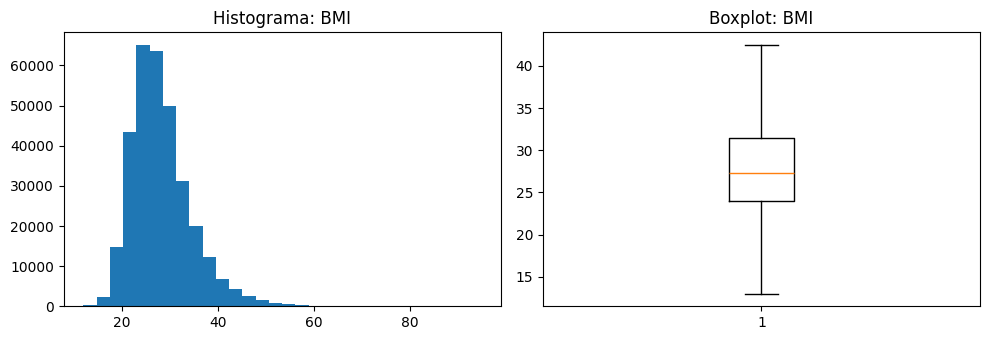

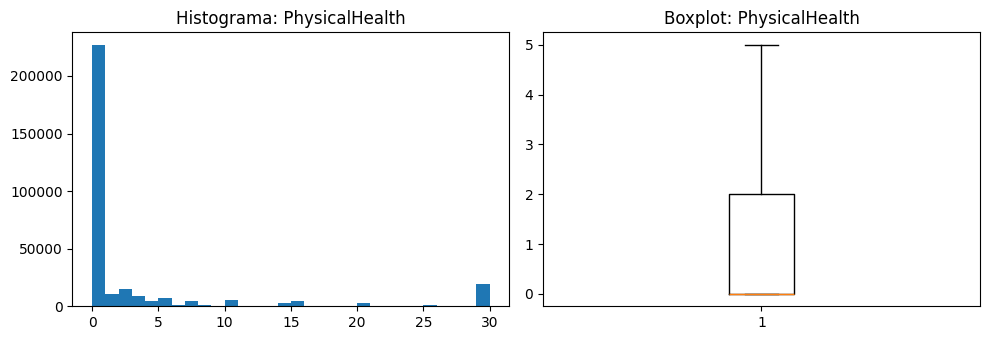

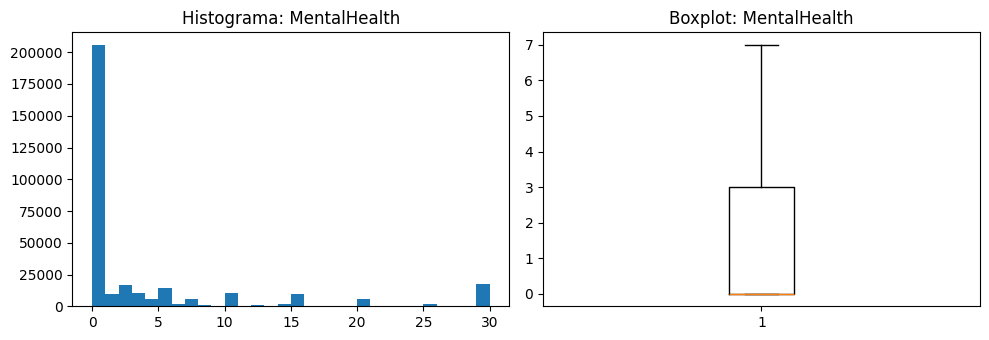

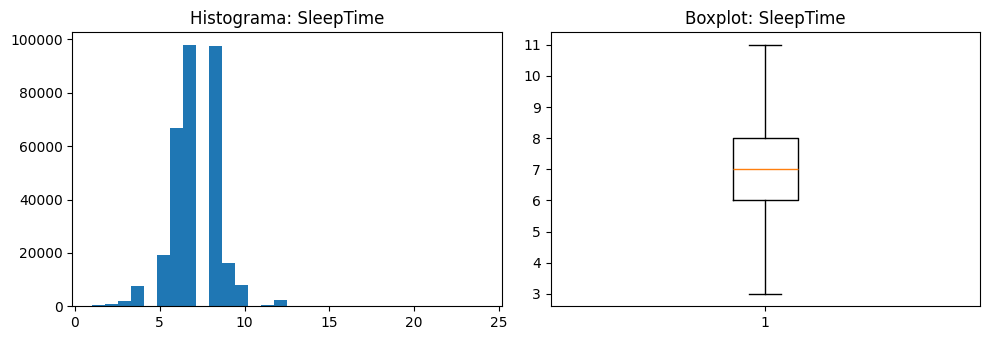

In [3]:

for col in num_cols[:6]:
    fig, ax = plt.subplots(1,2, figsize=(10,3.5))
    ax[0].hist(df[col].dropna(), bins=30); ax[0].set_title(f'Histograma: {col}')
    ax[1].boxplot(df[col].dropna(), vert=True, showfliers=False); ax[1].set_title(f'Boxplot: {col}')
    plt.tight_layout(); plt.show()


### 1.2 Univariado — Categóricas

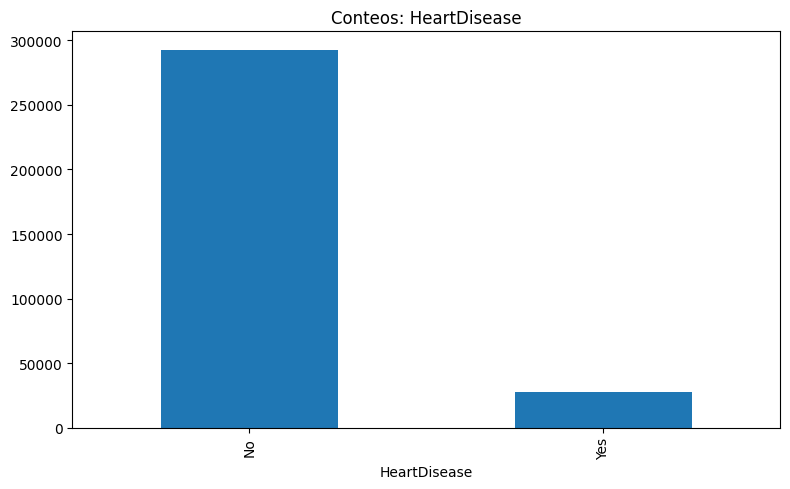

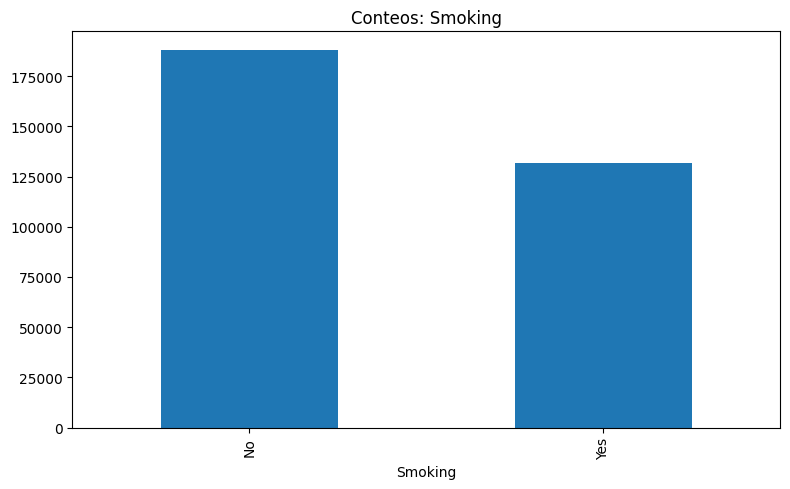

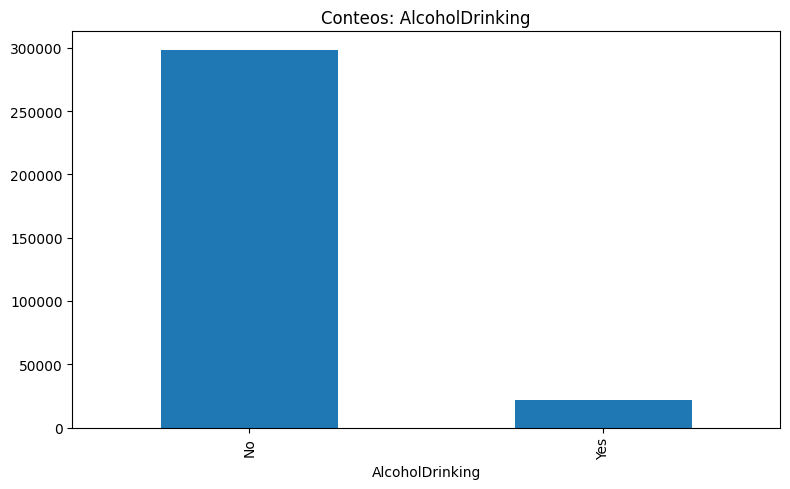

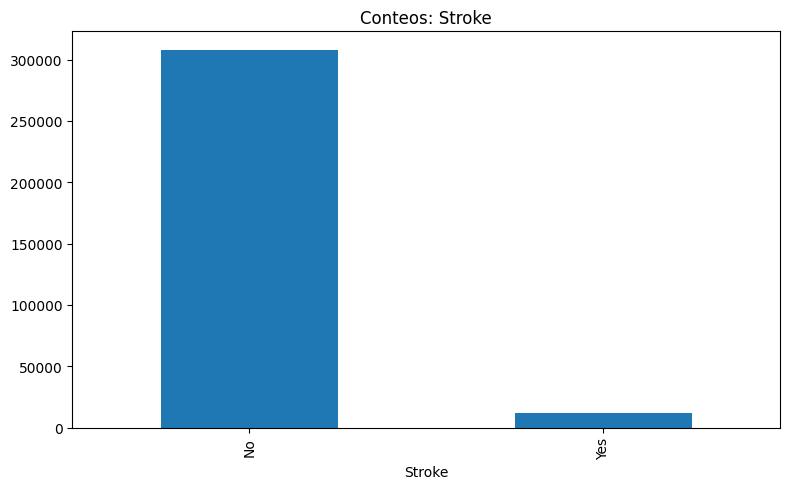

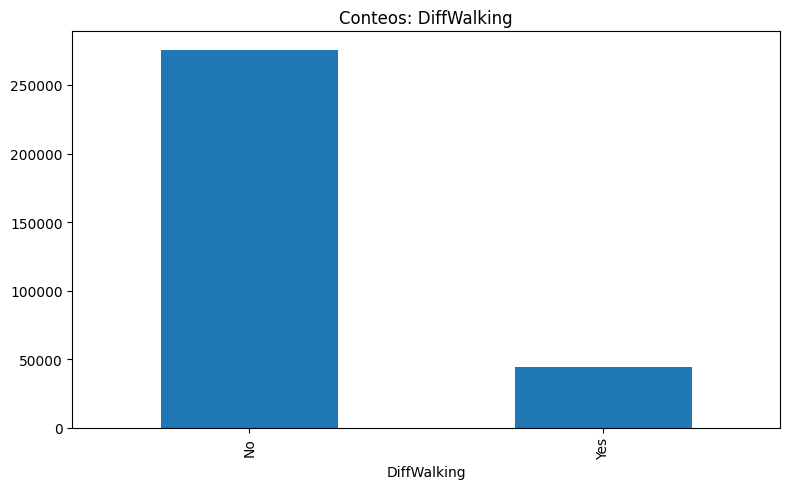

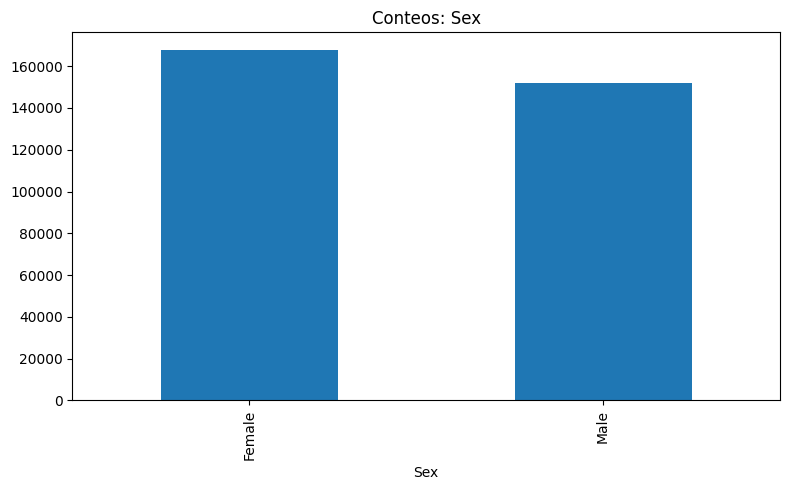

In [4]:

for col in cat_cols[:6]:
    df[col].astype(str).value_counts(dropna=False).head(20).plot(kind='bar', title=f'Conteos: {col}')
    plt.tight_layout(); plt.show()


### 1.3 Bivariado

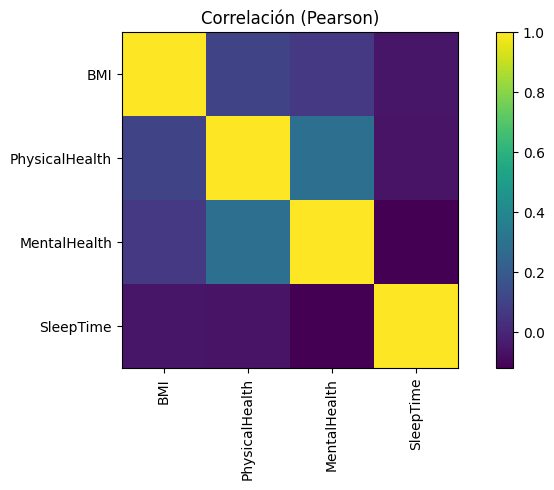

/tmp/ipython-input-938916940.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False); plt.title(f'{col} por {target}'); plt.tight_layout(); plt.show()


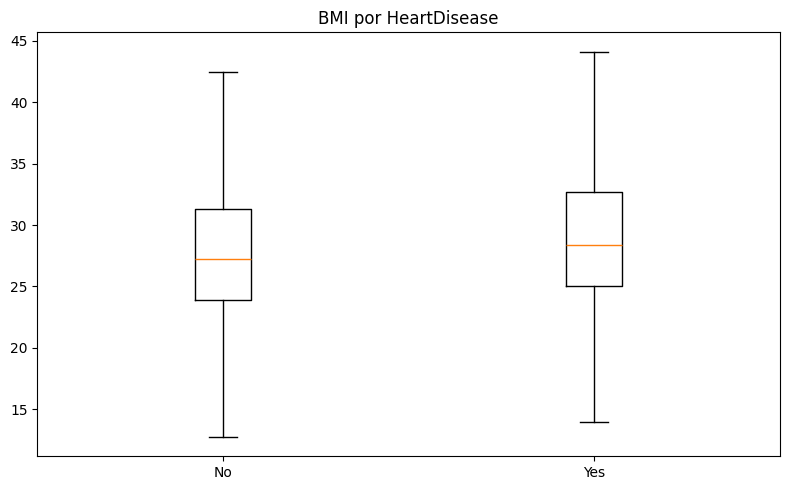

/tmp/ipython-input-938916940.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False); plt.title(f'{col} por {target}'); plt.tight_layout(); plt.show()


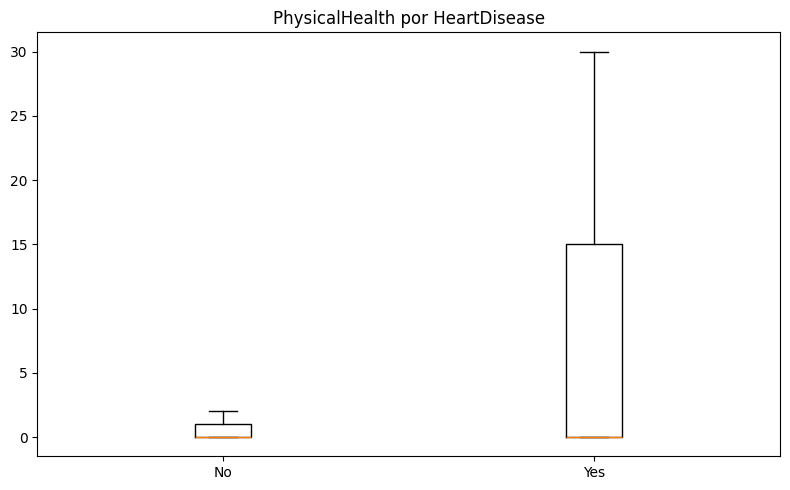

/tmp/ipython-input-938916940.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False); plt.title(f'{col} por {target}'); plt.tight_layout(); plt.show()


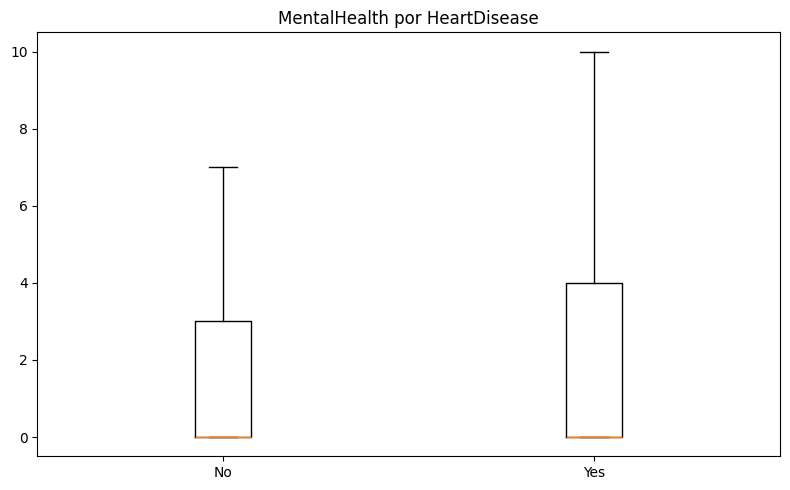

/tmp/ipython-input-938916940.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False); plt.title(f'{col} por {target}'); plt.tight_layout(); plt.show()


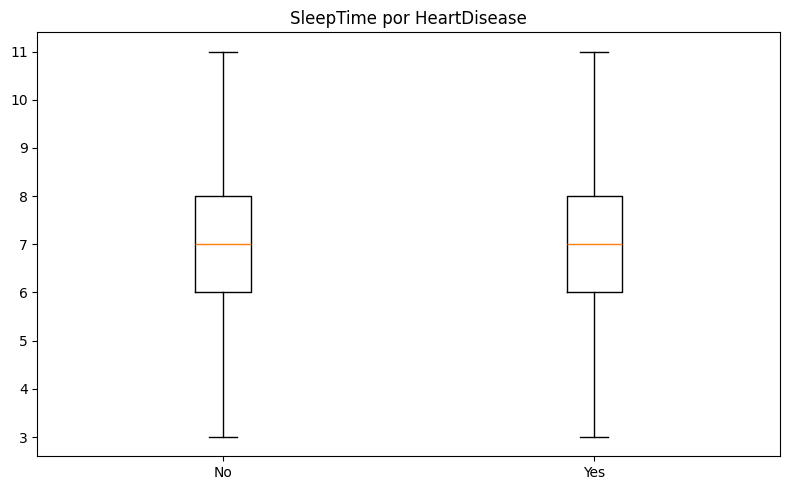

In [5]:

# Matriz de correlación (subset)
num_subset = num_cols[:10]
if len(num_subset) >= 2:
    corr = df[num_subset].corr()
    plt.imshow(corr, interpolation='nearest'); plt.xticks(range(len(num_subset)), num_subset, rotation=90)
    plt.yticks(range(len(num_subset)), num_subset); plt.title('Correlación (Pearson)'); plt.colorbar(); plt.tight_layout(); plt.show()

# Boxplots numéricas vs HeartDisease
if target:
    for col in num_cols[:4]:
        cats = df[target].astype(str).unique().tolist()
        data = [df.loc[df[target].astype(str)==c, col].dropna() for c in cats]
        plt.boxplot(data, labels=cats, showfliers=False); plt.title(f'{col} por {target}'); plt.tight_layout(); plt.show()


### 1.4 Multivariado (PCA)

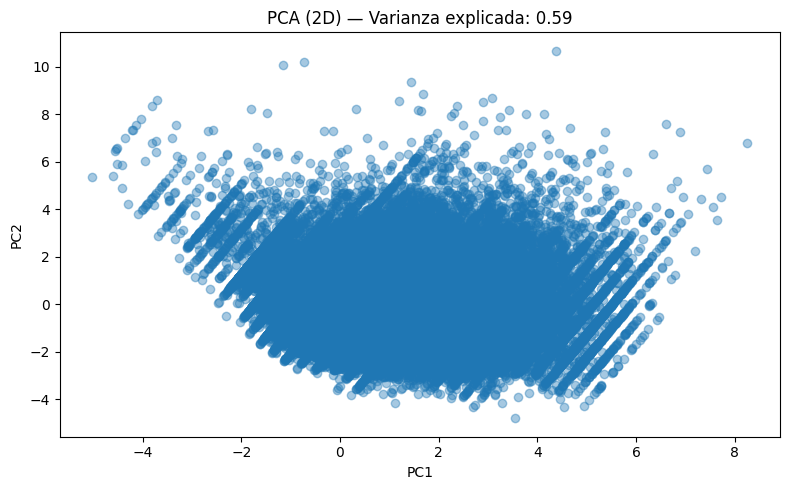

In [6]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
if len(num_cols) >= 2:
    nums = df[num_cols].copy()
    imp = SimpleImputer(strategy='median'); scl = StandardScaler()
    Xs = scl.fit_transform(imp.fit_transform(nums))
    pca = PCA(n_components=2, random_state=42); comps = pca.fit_transform(Xs)
    ve = pca.explained_variance_ratio_.sum()
    plt.scatter(comps[:,0], comps[:,1], alpha=0.4); plt.title(f'PCA (2D) — Varianza explicada: {ve:.2f}')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()


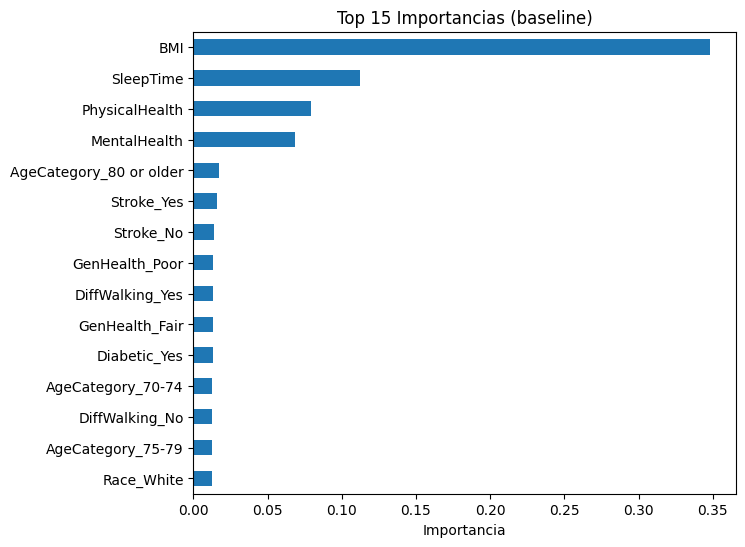

In [22]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if target is not None and target in df.columns:
    y = df[target]; X = df.drop(columns=[target])
    X_num = X.select_dtypes(include=[np.number]); X_cat = X.drop(columns=X_num.columns).astype('category')
    X_cat = pd.get_dummies(X_cat, dummy_na=True, drop_first=False)
    X_all = pd.concat([X_num, X_cat], axis=1)
    X_all = X_all.fillna(X_all.median(numeric_only=True))

    if y.nunique() <= 20:
        model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    else:
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

    model.fit(X_all, y)
    importances = pd.Series(model.feature_importances_, index=X_all.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(7,6)); importances.iloc[::-1].plot(kind='barh'); plt.title('Top 15 Importancias (baseline)'); plt.xlabel('Importancia'); plt.show()
else:
    print('No se detectó variable objetivo para importancias.')


#### Conclusiones (Sección 1)
- El dataset se cargó correctamente y contiene variables numéricas y categóricas útiles.
- Las distribuciones muestran posibles outliers; conviene monitorearlos antes del modelado.
- Se observan relaciones relevantes entre variables; el PCA ayuda a visualizar patrones globales.


## 2) Procesamiento, Split 80/20 y Modelo Logístico (baseline)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

def prepare_target(y: pd.Series) -> pd.Series:
    if y.dtype == object:
        y_str = y.astype(str).str.strip().str.lower()
        mapping_yes = {'yes','1','true','si','sí'}
        mapping_no  = {'no','0','false'}
        y_bin = y_str.map(lambda v: 1 if v in mapping_yes else (0 if v in mapping_no else np.nan))
        y_num = pd.to_numeric(y, errors='coerce')
        y_bin = y_bin.fillna(y_num)
        return y_bin.astype(int)
    return y.astype(int)

assert target is not None and target=='HeartDisease', 'No se encontró HeartDisease como objetivo.'
y = prepare_target(df['HeartDisease'])
X = df.drop(columns=['HeartDisease'])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

pre = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
pipe = Pipeline([('preprocess', pre), ('model', LogisticRegression(max_iter=1000, solver='lbfgs'))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
pipe.fit(X_train, y_train)

y_tr_pred = pipe.predict(X_train)
y_te_pred = pipe.predict(X_test)

import pandas as pd
def metrics_frame(y_true_tr, y_pred_tr, y_true_te, y_pred_te):
    rows = []
    for part, yt, yp in [('Train', y_true_tr, y_pred_tr), ('Test', y_true_te, y_pred_te)]:
        rows.append({'Split': part,
                     'Accuracy': accuracy_score(yt, yp),
                     'Precision': precision_score(yt, yp, zero_division=0),
                     'Recall': recall_score(yt, yp, zero_division=0),
                     'F1': f1_score(yt, yp, zero_division=0)})
    return pd.DataFrame(rows).set_index('Split')

baseline_metrics = metrics_frame(y_train, y_tr_pred, y_test, y_te_pred).round(3)
baseline_metrics

,Accuracy,Precision,Recall,F1
Split,,,,
Train,0.916,0.543,0.106,0.178
Test,0.917,0.565,0.107,0.180


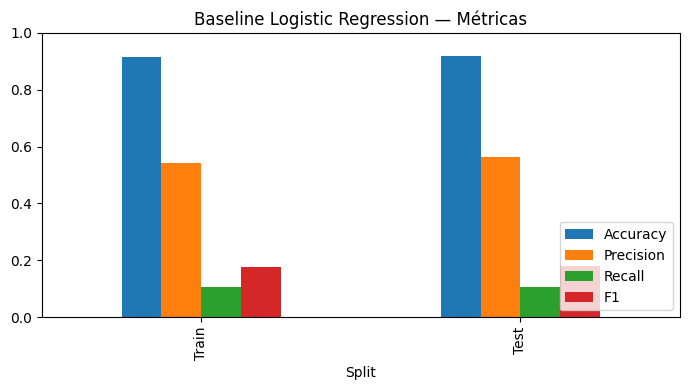

In [10]:

ax = baseline_metrics.plot(kind='bar', figsize=(7,4), title='Baseline Logistic Regression — Métricas')
ax.set_ylim(0,1); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()



**Conclusiones breves (Sección 2):**
- El modelo baseline de Regresión Logística se entrenó con 80% de los datos y se validó con 20% restantes.
- Se reportan métricas **Accuracy, Precision, Recall y F1** para interpretar desempeño general y detección de casos positivos.
- Las curvas **ROC** y las **matrices de confusión** complementan la lectura: si el objetivo es detectar el mayor número de positivos, conviene priorizar **Recall/F1** y evaluar **balanceo de clases** o **ajuste de umbral**.


## 3) Regularización (C), 5-Fold CV y Balanceo

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
C_GRID = [1, 0.5, 0.1, 0.01, 0.001, 0.0001, 0.000001]

def make_pipeline(C=1.0, class_weight=None):
    pre = ColumnTransformer([
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    clf = LogisticRegression(max_iter=1000, solver="lbfgs", C=C, class_weight=class_weight)
    return Pipeline([("preprocess", pre), ("model", clf)])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for C in C_GRID:
    pipeC = make_pipeline(C=C)
    scores = cross_val_score(pipeC, X_train, y_train, cv=kf, scoring="f1")
    cv_results.append((C, scores.mean(), scores.std()))
cv_df = pd.DataFrame(cv_results, columns=["C","F1_mean","F1_std"]).sort_values("F1_mean", ascending=False)
cv_df

,C,F1_mean,F1_std
1,0.500000,0.177376,0.002878
0,1.000000,0.177300,0.002911
2,0.100000,0.176943,0.003045
3,0.010000,0.165826,0.002847
4,0.001000,0.106619,0.004094
5,0.000100,0.000456,0.000289
6,0.000001,0.000000,0.000000


In [17]:
best_C = float(cv_df.iloc[0]["C"])
best_pipe = make_pipeline(C=best_C)
best_pipe.fit(X_train, y_train)
y_tr_pred_best = best_pipe.predict(X_train); y_te_pred_best = best_pipe.predict(X_test)
reg_metrics = metrics_frame(y_train, y_tr_pred_best, y_test, y_te_pred_best).round(3)
reg_metrics

,Accuracy,Precision,Recall,F1
Split,,,,
Train,0.916,0.543,0.106,0.178
Test,0.916,0.564,0.107,0.180


### 3.1 Balanceo: Weighted, Oversampling y Undersampling

In [19]:
from sklearn.utils import resample
# Weighted
pipe_w = make_pipeline(C=best_C, class_weight="balanced")
pipe_w.fit(X_train, y_train)
y_tr_pred_w = pipe_w.predict(X_train); y_te_pred_w = pipe_w.predict(X_test)
weighted_metrics = metrics_frame(y_train, y_tr_pred_w, y_test, y_te_pred_w).round(3)

# Oversampling / Undersampling (en espacio transformado)
pre_only = best_pipe.named_steps["preprocess"] if 'best_pipe' in globals() else make_pipeline(C=best_C).named_steps["preprocess"]
pre_only.fit(X_train, y_train)
Xtr_enc = pre_only.transform(X_train); Xte_enc = pre_only.transform(X_test)

pos_mask = (y_train==1)
X_pos, y_pos = Xtr_enc[pos_mask], y_train[pos_mask]
X_neg, y_neg = Xtr_enc[~pos_mask], y_train[~pos_mask]

# Oversampling
import numpy as np, pandas as pd
if len(y_pos) < len(y_neg):
    X_pos_up, y_pos_up = resample(X_pos, y_pos, replace=True, n_samples=len(y_neg), random_state=42)
    X_over = np.vstack([X_neg, X_pos_up]); y_over = pd.concat([y_neg, y_pos_up])
else:
    X_neg_up, y_neg_up = resample(X_neg, y_neg, replace=True, n_samples=len(y_pos), random_state=42)
    X_over = np.vstack([X_pos, X_neg_up]); y_over = pd.concat([y_pos, y_neg_up])

clf_over = LogisticRegression(max_iter=1000, solver="lbfgs", C=best_C)
clf_over.fit(X_over, y_over)
y_tr_pred_over = clf_over.predict(Xtr_enc); y_te_pred_over = clf_over.predict(Xte_enc)
oversampling_metrics = metrics_frame(y_train, y_tr_pred_over, y_test, y_te_pred_over).round(3)

# Undersampling
if len(y_pos) > len(y_neg):
    X_pos_down, y_pos_down = resample(X_pos, y_pos, replace=False, n_samples=len(y_neg), random_state=42)
    X_under = np.vstack([X_neg, X_pos_down]); y_under = pd.concat([y_neg, y_pos_down])
else:
    X_neg_down, y_neg_down = resample(X_neg, y_neg, replace=False, n_samples=len(y_pos), random_state=42)
    X_under = np.vstack([X_pos, X_neg_down]); y_under = pd.concat([y_pos, y_neg_down])

clf_under = LogisticRegression(max_iter=1000, solver="lbfgs", C=best_C)
clf_under.fit(X_under, y_under)
y_tr_pred_under = clf_under.predict(Xtr_enc); y_te_pred_under = clf_under.predict(Xte_enc)
undersampling_metrics = metrics_frame(y_train, y_tr_pred_under, y_test, y_te_pred_under).round(3)

all_tables = {
    "Baseline": baseline_metrics,
    f"Regularizado (C={best_C})": reg_metrics,
    "Weighted (balanced)": weighted_metrics,
    "Oversampling": oversampling_metrics,
    "Undersampling": undersampling_metrics
}
all_tables

{'Baseline':        Accuracy  Precision  Recall     F1
 Split                                    
 Train     0.916      0.543   0.106  0.178
 Test      0.917      0.565   0.107  0.180,
 'Regularizado (C=0.5)':        Accuracy  Precision  Recall     F1
 Split                                    
 Train     0.916      0.543   0.106  0.178
 Test      0.916      0.564   0.107  0.180,
 'Weighted (balanced)':        Accuracy  Precision  Recall     F1
 Split                                    
 Train     0.750      0.225   0.783  0.350
 Test      0.749      0.222   0.775  0.346,
 'Oversampling':        Accuracy  Precision  Recall     F1
 Split                                    
 Train     0.751      0.225   0.783  0.350
 Test      0.749      0.223   0.775  0.346,
 'Undersampling':        Accuracy  Precision  Recall     F1
 Split                                    
 Train     0.751      0.225   0.783  0.350
 Test      0.749      0.222   0.775  0.346}

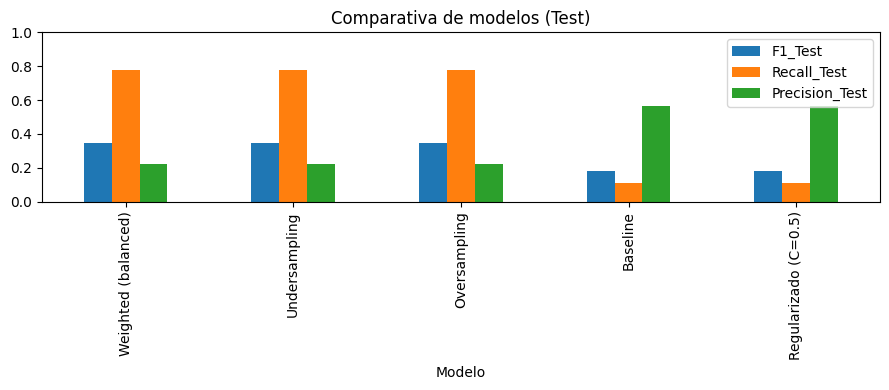

,Modelo,F1_Test,Recall_Test,Precision_Test
2,Weighted (balanced),0.346,0.775,0.222
4,Undersampling,0.346,0.775,0.222
3,Oversampling,0.346,0.775,0.223
0,Baseline,0.180,0.107,0.565
1,Regularizado (C=0.5),0.180,0.107,0.564


In [20]:
comp = []
for name, dfm in all_tables.items():
    comp.append({"Modelo": name, "F1_Test": float(dfm.loc["Test","F1"]),
                 "Recall_Test": float(dfm.loc["Test","Recall"]),
                 "Precision_Test": float(dfm.loc["Test","Precision"])})
comp_df = pd.DataFrame(comp).sort_values("F1_Test", ascending=False)
comp_df.plot(x="Modelo", y=["F1_Test","Recall_Test","Precision_Test"], kind="bar", figsize=(9,4), title="Comparativa de modelos (Test)")
plt.ylim(0,1); plt.tight_layout(); plt.show()
comp_df

#### Conclusiones (Sección 3)


- **Logístico simple**: base de comparación; puede tener alta accuracy pero bajo recall si hay desbalance.
- **Logístico + Regularización**: estabiliza y controla complejidad; su ganancia depende del patrón de datos.
- **Logístico + Balanceo**: `class_weight='balanced'`, oversampling y undersampling **aumentan el recall** a costa de precisión. Elegir el compromiso según el objetivo (no perder positivos vs. evitar falsos positivos).
